In [1]:
#importing necessary libraries
import pandas as pd # for managing the data
import numpy as np # for mathematical operations
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#Ensuring plot folder exists
os.makedirs("plots", exist_ok=True)

In [3]:
!pip install xlrd

In [4]:
#loading the dataset and checking top 5
df = pd.read_excel("nga_subnational_covid19_hera.xls")
df.head()

,ID,DATE,ISO_3,PAYS,ID_PAYS,REGION,ID_REGION,CONTAMINES,DECES,GUERIS,CONTAMINES_FEMME,CONTAMINES_HOMME,CONTAMINES_GENRE_NON_SPECIFIE,SOURCE
0,1,2020-02-27,NGA,Nigéria,15,Abia,170,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control
1,2,2020-02-27,NGA,Nigéria,15,Adamawa,171,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control
2,3,2020-02-27,NGA,Nigéria,15,Akwa Ibom,172,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control
3,4,2020-02-27,NGA,Nigéria,15,Anambra,173,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control
4,5,2020-02-27,NGA,Nigéria,15,Bauchi,174,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control


In [5]:
#checking last row
df.tail(1)

,ID,DATE,ISO_3,PAYS,ID_PAYS,REGION,ID_REGION,CONTAMINES,DECES,GUERIS,CONTAMINES_FEMME,CONTAMINES_HOMME,CONTAMINES_GENRE_NON_SPECIFIE,SOURCE
26865,26866,2022-02-02,NGA,Nigéria,15,Non spécifié,207,0.0,0.0,0.0,0.0,0.0,0.0,Nigeria Centre for Disease Control


In [6]:
#checking columns name
df.columns

Index(['ID', 'DATE', 'ISO_3', 'PAYS', 'ID_PAYS', 'REGION', 'ID_REGION',
       'CONTAMINES', 'DECES', 'GUERIS', 'CONTAMINES_FEMME', 'CONTAMINES_HOMME',
       'CONTAMINES_GENRE_NON_SPECIFIE', 'SOURCE'],
      dtype='object')

**Understanding Columns (Nigeria Dataset)** 

Here’s the meaning of each column:
| Column Name                | Description                                                    |
|----------------------------|----------------------------------------------------------------|
| ID                         | Unique row identifier                                          |
| DATE                       | Date of report                                                 |
| ISO_3                      | 3-letter country code                                          |
| PAYS                       | Country name                                                   |
| ID_PAYS                    | Country numeric ID                                             |
| REGION                     | Region name                                                    |
| ID_REGION                  | Region numeric ID                                              |
| CONTAMINES                 | Cumulative COVID-19 cases                                      |
| DECES                      | Cumulative deaths                                              |
| GUERIS                     | Cumulative recoveries                                         |
| CONTAMINES_FEMME           | Cumulative cases in females                                    |
| CONTAMINES_HOMME           | Cumulative cases in males                                      |
| CONTAMINES_GENRE_NON_SPECIFIE | Cases with unspecified gender                                 |
| SOURCE                     | Source of data                                                 |

In [8]:
df = df.drop(columns=[
    'ID',
    'ISO_3',
    'PAYS',
    'ID_PAYS',
    'SOURCE'
])

**Identifier and country-level metadata columns were removed as the analysis focused on regional time-series trends within Nigeria. These fields provided no analytical variance and were excluded to streamline processing.**

In [10]:
# checking number of rows and columns
df.shape

(26866, 9)

In [11]:
#checking information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26866 entries, 0 to 26865
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   DATE                           26866 non-null  datetime64[ns]
 1   REGION                         26866 non-null  object        
 2   ID_REGION                      26866 non-null  int64         
 3   CONTAMINES                     26802 non-null  float64       
 4   DECES                          26463 non-null  float64       
 5   GUERIS                         26280 non-null  float64       
 6   CONTAMINES_FEMME               17734 non-null  float64       
 7   CONTAMINES_HOMME               17734 non-null  float64       
 8   CONTAMINES_GENRE_NON_SPECIFIE  23663 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 1.8+ MB


###### From the results above, 
it can be seen that some columns have missing values as not all columns has 1309 entries,
also, some columns has incorrect data type e.g DECES, GUERIS ETC

In [13]:
#Detecting only missing columns
#In complete data could break analysis if not handled
df.isna().sum()[df.isna().sum() > 0]


CONTAMINES                         64
DECES                             403
GUERIS                            586
CONTAMINES_FEMME                 9132
CONTAMINES_HOMME                 9132
CONTAMINES_GENRE_NON_SPECIFIE    3203
dtype: int64

In [14]:
negatives = df[(df['GUERIS'] < 0) | (df['CONTAMINES_HOMME'] < 0) | (df['CONTAMINES'] < 0)]
negatives

,DATE,REGION,ID_REGION,CONTAMINES,DECES,GUERIS,CONTAMINES_FEMME,CONTAMINES_HOMME,CONTAMINES_GENRE_NON_SPECIFIE
4483,2020-06-23,Non spécifié,207,0.0,0.0,0.0,542.0,-90.0,0.0
23799,2021-11-14,Edo,181,0.0,8.0,-46.0,0.0,0.0,0.0
24323,2021-11-28,Anambra,173,-1.0,0.0,0.0,NaN,NaN,-1.0
25923,2022-01-09,Borno,177,0.0,0.0,-11.0,0.0,0.0,0.0


In [15]:
#df['CONTAMINES'] = df['CONTAMINES'].replace(-1, np.nan)

In [16]:
cols = ['CONTAMINES', 'GUERIS','CONTAMINES_HOMME']

df[cols] = df[cols].mask(df[cols] < 0, np.nan)

In [17]:
negatives = df[(df['GUERIS'] < 0) | (df['CONTAMINES_HOMME'] < 0) | (df['CONTAMINES'] < 0)]
negatives

,DATE,REGION,ID_REGION,CONTAMINES,DECES,GUERIS,CONTAMINES_FEMME,CONTAMINES_HOMME,CONTAMINES_GENRE_NON_SPECIFIE


## Handling missing values
this involves filling or removing empty entries in the dataset

In [19]:
cols_to_missing_int = [
    'CONTAMINES',
    'DECES',
    'GUERIS',
    'CONTAMINES_FEMME',
    'CONTAMINES_HOMME',
    'CONTAMINES_GENRE_NON_SPECIFIE'
]

In [20]:
#Forward Filling Cumulative Columns: Since these columns are cumulative totals:
df[cols_to_missing_int] = df.groupby('REGION')[cols_to_missing_int].ffill()

In [21]:
df[cols_to_missing_int] = df[cols_to_missing_int].fillna(0)

** Missing values represent unreported data, while zeros represent no cases reported. 
Forward-filling cumulative totals preserves the correct time series without introducing artificial zeros. 
Only the very first missing values per region are filled with 0, indicating no cumulative cases at the start.**

**Fixing Incorrect Data Type**

In [24]:
# Convert to Integer
df["ID_REGION"] = df["ID_REGION"].astype("str")

In [25]:
df[cols_to_missing_int] = df[cols_to_missing_int].astype(int)

#### Validating the cleaned dataset
This involves rechecking the dataset after cleaning so as to confirm all data quality issues have been resolved successfully

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26866 entries, 0 to 26865
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   DATE                           26866 non-null  datetime64[ns]
 1   REGION                         26866 non-null  object        
 2   ID_REGION                      26866 non-null  object        
 3   CONTAMINES                     26866 non-null  int32         
 4   DECES                          26866 non-null  int32         
 5   GUERIS                         26866 non-null  int32         
 6   CONTAMINES_FEMME               26866 non-null  int32         
 7   CONTAMINES_HOMME               26866 non-null  int32         
 8   CONTAMINES_GENRE_NON_SPECIFIE  26866 non-null  int32         
dtypes: datetime64[ns](1), int32(6), object(2)
memory usage: 1.2+ MB


In [28]:
# checking the missing columns again
df.isna().sum()[df.isna().sum() > 0]


Series([], dtype: int64)

In [29]:
#sorting values for computation
df = df.sort_values(['REGION', 'DATE'])


In [30]:
#Compute daily new cases (from cumulative)
cum_cols = ['CONTAMINES','DECES','GUERIS','CONTAMINES_FEMME','CONTAMINES_HOMME','CONTAMINES_GENRE_NON_SPECIFIE']

for col in cum_cols:
    df[f'Daily_{col}'] = df.groupby('REGION')[col].diff()
    df[f'Daily_{col}'] = df[f'Daily_{col}'].fillna(df[col])
    df[f'Daily_{col}'] = df[f'Daily_{col}'].clip(lower=0)


In [31]:
#Compute weekly totals per region
weekly_cases = df.set_index('DATE').groupby('REGION')['Daily_CONTAMINES'].resample('W-MON').sum().reset_index()
weekly_cases.rename(columns={'Daily_CONTAMINES':'Weekly_Contamines'}, inplace=True)

In [32]:
#Compute rolling averages
# 7-day rolling for daily cases
df['Daily_Rolling_7'] = df.groupby('REGION')['Daily_CONTAMINES'].rolling(7).mean().reset_index(0,drop=True)
# 4-week rolling for weekly cases
weekly_cases['Weekly_Rolling_4'] = weekly_cases.groupby('REGION')['Weekly_Contamines'].rolling(4).mean().reset_index(0,drop=True)


In [33]:
#Peak detection (simple approach)
# Daily peaks per region
peak_daily = df.groupby('REGION')['Daily_CONTAMINES'].max().reset_index()
peak_daily.rename(columns={'Daily_CONTAMINES':'Peak_Daily'}, inplace=True)

In [34]:
#Weekly peaks per region
peak_weekly = weekly_cases.groupby('REGION')['Weekly_Contamines'].max().reset_index()
peak_weekly.rename(columns={'Weekly_Contamines':'Peak_Weekly'}, inplace=True)


In [35]:
#Estimate basic reproduction indicator (Rt approximation)
# Rt ~ Daily cases / Daily cases 7 days ago
df['Rt_Approx'] = df.groupby('REGION')['Daily_CONTAMINES'].transform(lambda x: x / x.shift(7))
# Replace inf and clip
df['Rt_Approx'] = df['Rt_Approx'].replace([np.inf, -np.inf], np.nan).clip(lower=0, upper=10)

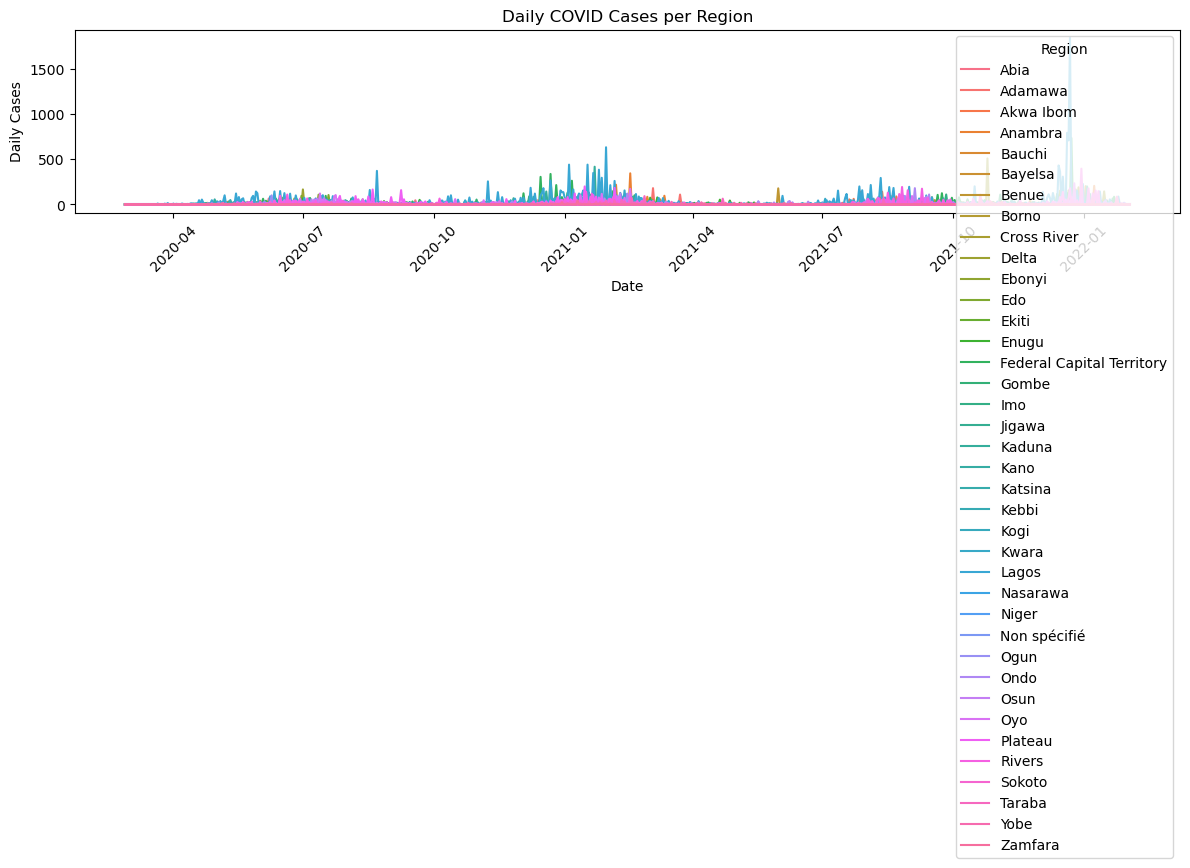

In [36]:
 #Daily cases per region
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='DATE', y='Daily_CONTAMINES', hue='REGION')
plt.title('Daily COVID Cases per Region')
plt.ylabel('Daily Cases')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig("plots/daily_cases_per_region.png")
plt.show()


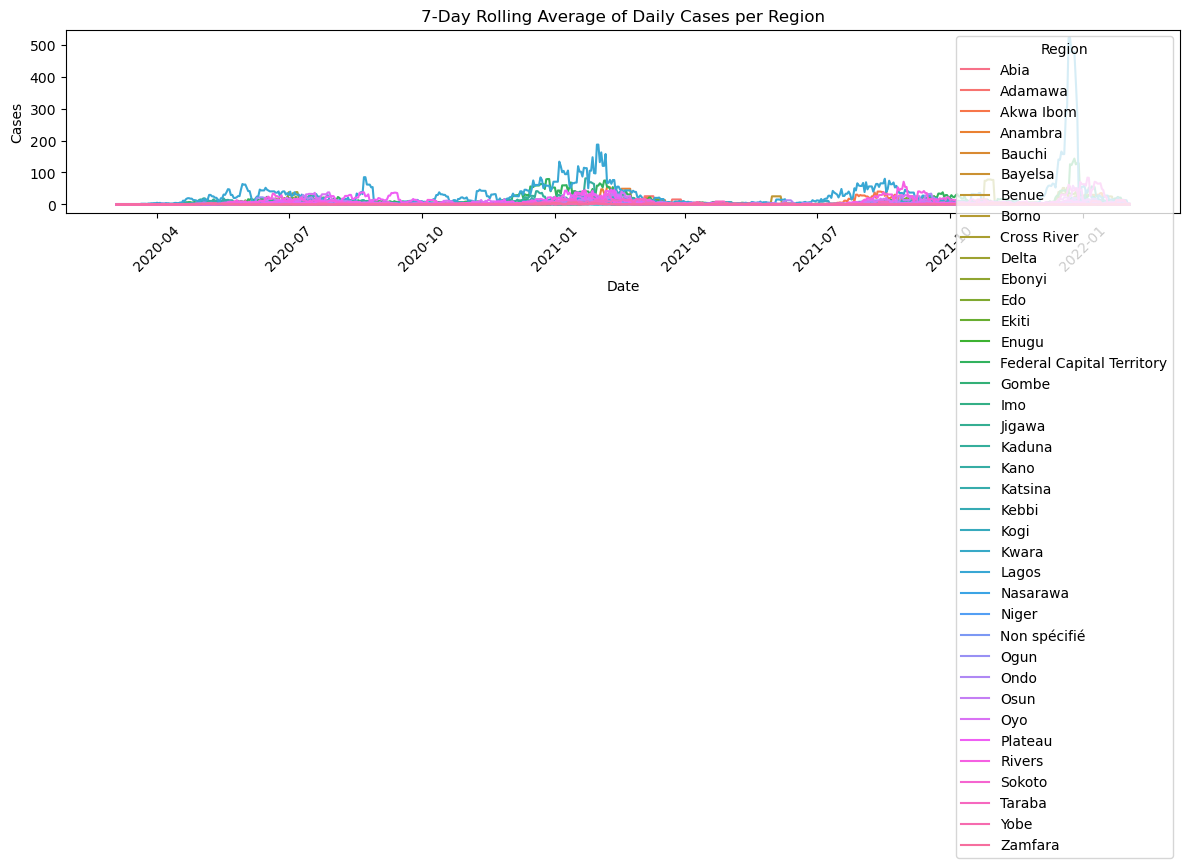

In [37]:
# 7-day rolling daily cases
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='DATE', y='Daily_Rolling_7', hue='REGION')
plt.title('7-Day Rolling Average of Daily Cases per Region')
plt.ylabel('Cases')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig("plots/rolling_daily_cases_per_region.png")
plt.show()


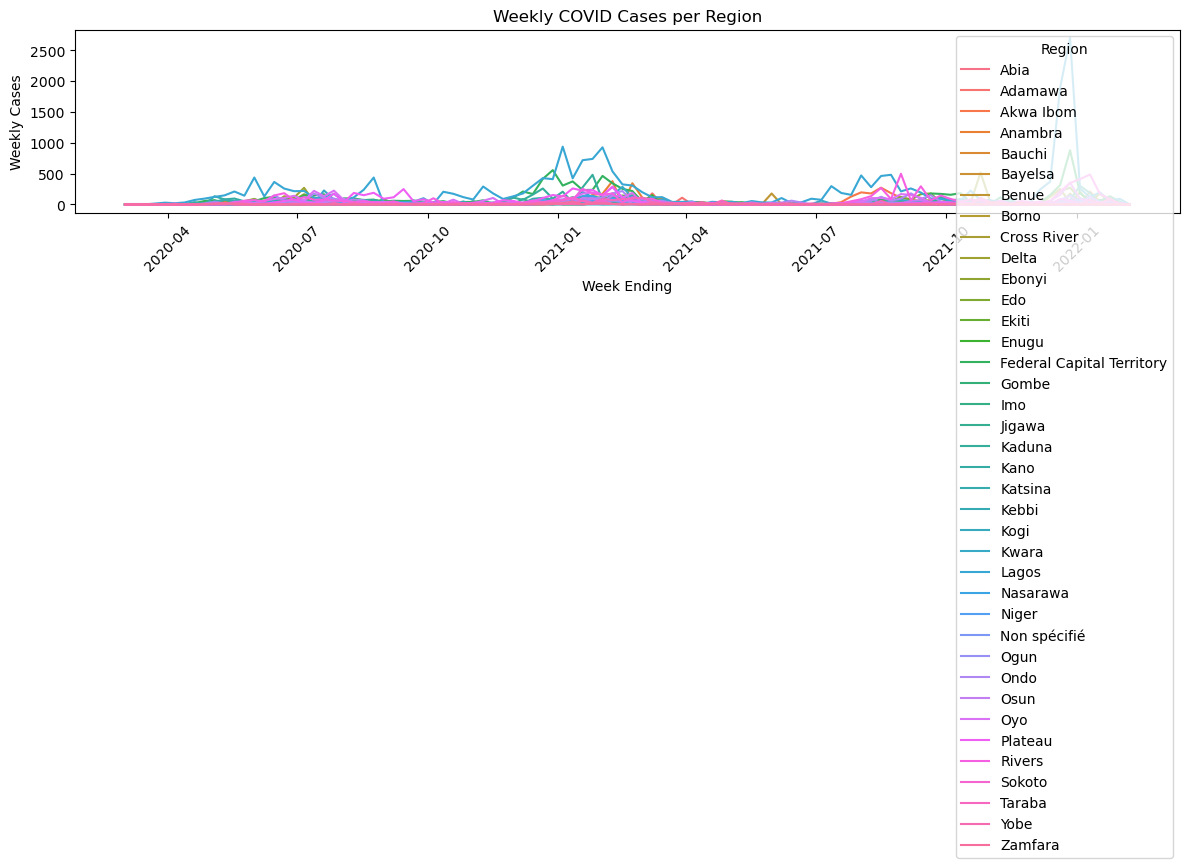

In [38]:
# Weekly cases per region
plt.figure(figsize=(12,6))
sns.lineplot(data=weekly_cases, x='DATE', y='Weekly_Contamines', hue='REGION')
plt.title('Weekly COVID Cases per Region')
plt.ylabel('Weekly Cases')
plt.xlabel('Week Ending')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig("plots/weekly_cases_per_region.png")
plt.show()


In [39]:
# Save datasets
df.to_csv("nigeria_covid_daily_cases_full.csv", index=False)
weekly_cases.to_csv("nigeria_covid_weekly_cases.csv", index=False)
peak_daily.to_csv("nigeria_covid_peak_daily.csv", index=False)
peak_weekly.to_csv("nigeria_covid_peak_weekly.csv", index=False)


In [40]:
#Export brief summary text
summary_text = f"""
Nigeria COVID-19 Data Analysis Summary

- Total Regions: {df['REGION'].nunique()}
- Total Days: {df['DATE'].nunique()}
- Peak daily cases by region:
{peak_daily.to_string(index=False)}

- Peak weekly cases by region:
{peak_weekly.to_string(index=False)}

- Daily rolling averages computed (7-day)
- Weekly rolling averages computed (4-week)
- Approximate reproduction numbers (Rt) calculated per region
- Datasets and plots saved in CSV and 'plots/' folder.
"""

with open("nigeria_covid_summary.txt", "w") as f:
    f.write(summary_text)

print("Analysis complete. Datasets, plots, and summary saved.")

Analysis complete. Datasets, plots, and summary saved.
